In [9]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, TensorDataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt
import importlib
import my_bar
import os
import sys
importlib.reload(my_bar)

<module 'my_bar' from '/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/code/my_bar.py'>

In [10]:
ours = True

In [11]:
if ours:
    x_numpy, y_numpy = my_bar.load_experimental_data()
else:
    x_numpy, y_numpy = my_bar.load_sciro_data()

x_numpy shape: (1138, 10)
y_numpy shape: (1138, 2)


In [12]:
x_numpy = x_numpy[:, 1]

In [13]:
x_normalized, x_means, x_stds = my_bar.normalize(x_numpy)
y_normalized, y_means, y_stds = my_bar.normalize(y_numpy)

In [14]:
if True:
    x_numpy = x_normalized
    y_numpy = y_normalized

In [15]:
x_train, y_train, x_val, y_val, x_test, y_test = my_bar.train_validation_test(x_numpy, y_numpy)

In [16]:
num_samples = x_numpy.shape[0]
# num_input_dims = x_numpy.shape[1]
num_output_dims = y_numpy.shape[1]
sequence_length = 10

x_train_chunked, y_train_chunked = my_bar.chunk_sequence(x_train, y_train, sequence_length)
x_val_chunked, y_val_chunked = my_bar.chunk_sequence(x_val, y_val, sequence_length)
x_test_chunked, y_test_chunked = my_bar.chunk_sequence(x_test, y_test, sequence_length)

IndexError: tuple index out of range

In [ ]:
train_loader = my_bar.prepare_dataloader(x_train, y_train, 16, True)
val_loader = my_bar.prepare_dataloader(x_val, y_val, 16, False)
test_loader = my_bar.prepare_dataloader(x_test, y_test, 16, False)

In [ ]:
# Define the fully connected network
class FCNN(pl.LightningModule):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        hidden_dim = 50
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss_fn(preds, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss_fn(preds, y)
        self.log("val_loss", loss)

    def test_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss_fn(preds, y)
        self.log("test_loss", loss)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

# Initialize the model
model = FCNN(sequence_length, num_output_dims)

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min"
)

# Train the model
trainer = pl.Trainer(
    max_epochs=50,
    callbacks=[early_stopping],
    log_every_n_steps=10
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(model, train_loader, val_loader)


  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | model   | Sequential | 3.2 K  | train
1 | loss_fn | MSELoss    | 0      | train
-----------------------------------------------
3.2 K     Trainable params
0         Non-trainable params
3.2 K     Total params
0.013     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

y_pred shape: torch.Size([171, 2])
y_test shape: torch.Size([171, 2])
Mean Squared Error (PyTorch): 1e+03
Mean Squared Error (PyTorch): 9.8572e+02


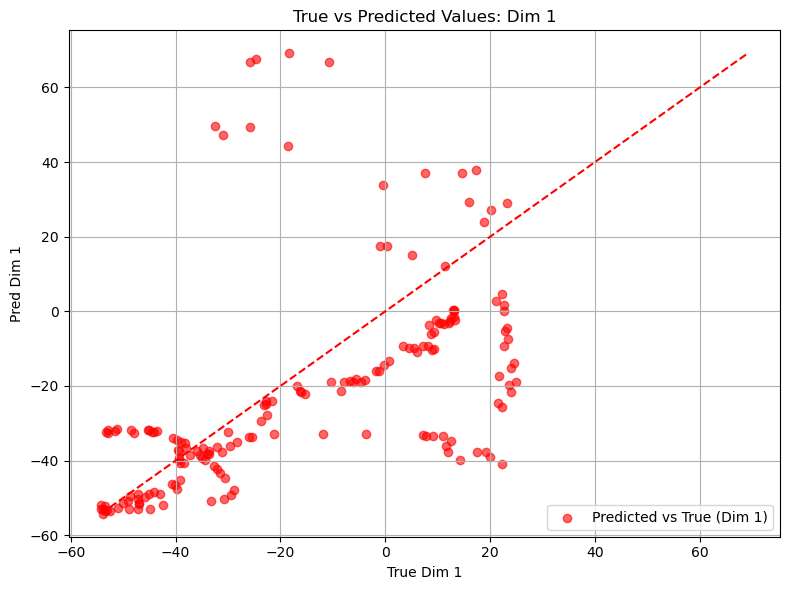

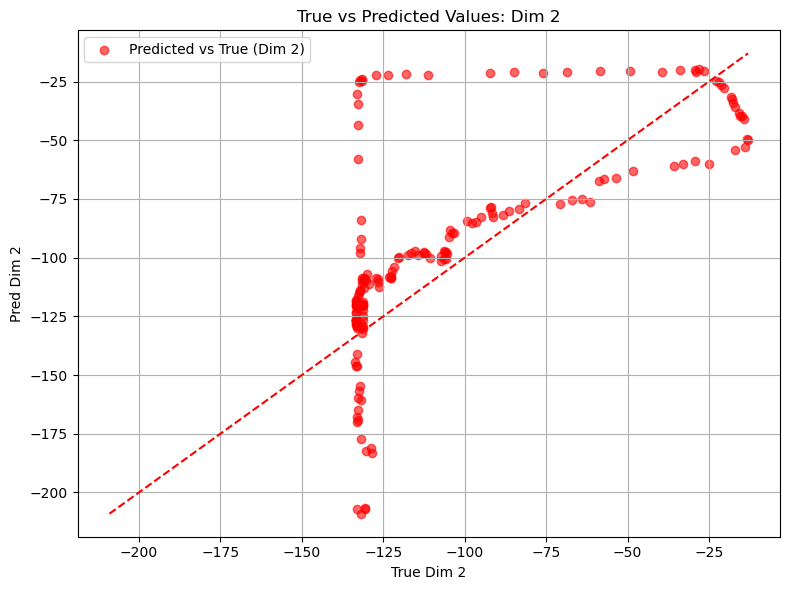

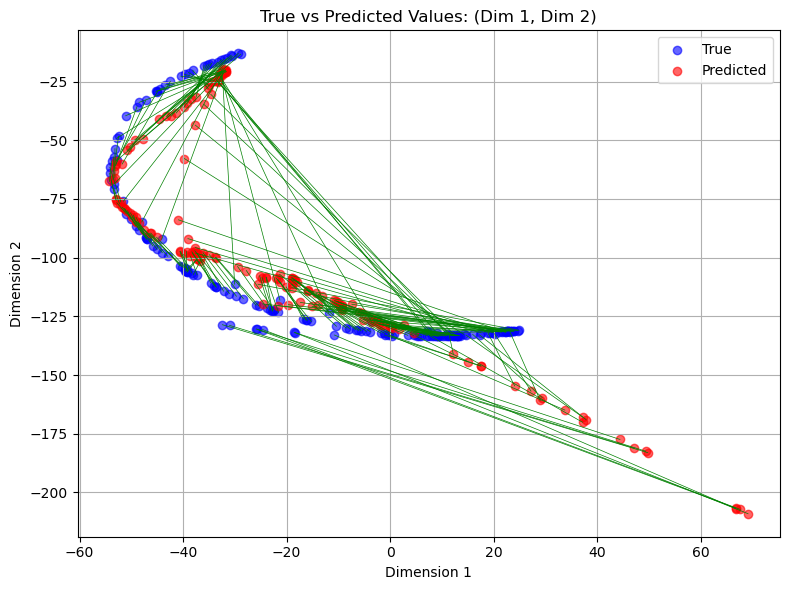

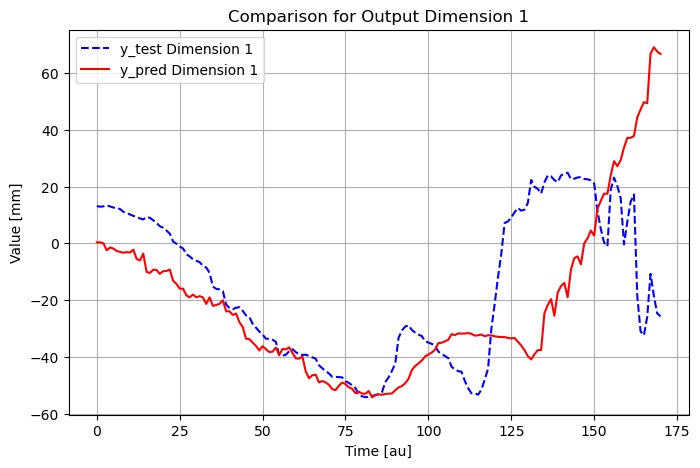

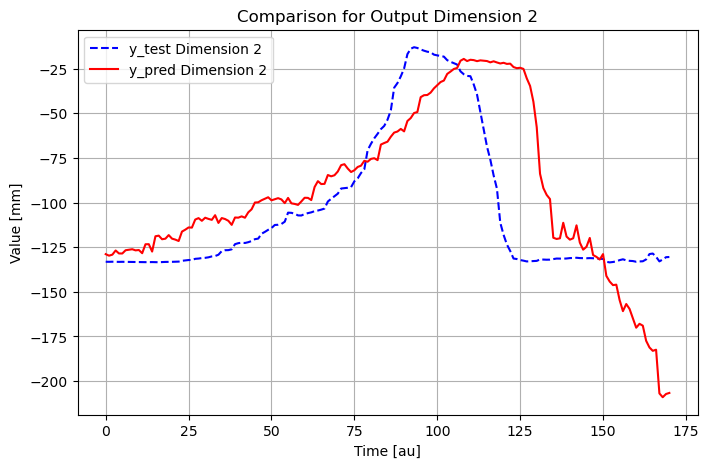

In [ ]:
y_test, y_pred = my_bar.test_model(model, test_loader)
y_test_denormalised = my_bar.denormalize(y_test, y_means, y_stds)
y_pred_denormalised = my_bar.denormalize(y_pred, y_means, y_stds)
my_bar.print_mse(y_test_denormalised, y_pred_denormalised)
my_bar.plot_data(y_test_denormalised, y_pred_denormalised)